In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
from ot.datasets import make_1D_gauss as gauss

In [12]:
# Generate data
n = 100 # nb bins
n_target = 20 # nb target distributions

# bin positions
x = np.arange(n, dtype=np.float64)

lst_m = np.linspace(20, 90, n_target)

# Gaussian distributions
a = gauss(n, m=20, s=5)

B = np.zeros((n, n_target))

for i, m in enumerate(lst_m):
  B[:, i] = gauss(n, m=m, s=5)
  
# loss matrix and normalization
M = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)), "euclidean")
M /= M.max() * 0.1
M2= ot.dist(x.reshape((n, 1)), x.reshape((n, 1)), "sqeuclidean")
M2 /= M2.max() * 0.1

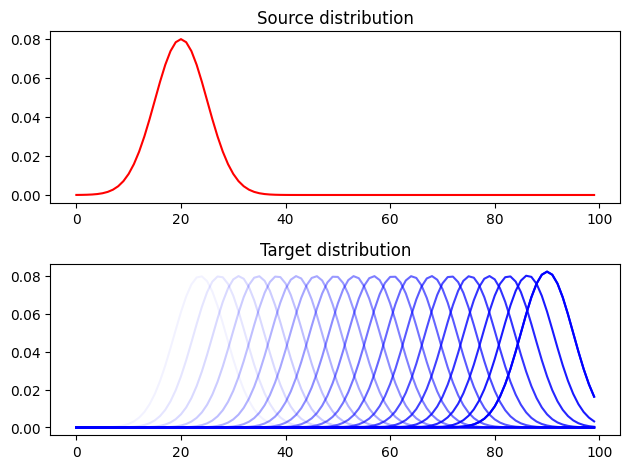

In [13]:
# Plot data
pl.figure(1)
pl.subplot(2, 1, 1)
pl.plot(x, a, "r", label="Source distribution")
pl.title("Source distribution")

pl.subplot(2, 1, 2)
for i in range(n_target):
  pl.plot(x, B[:, i], "b", alpha=i / n_target)
pl.plot(x, B[:, -1], "b", label="Target distributions")
pl.title("Target distribution")
pl.tight_layout()

## Compute EMD for the different losses

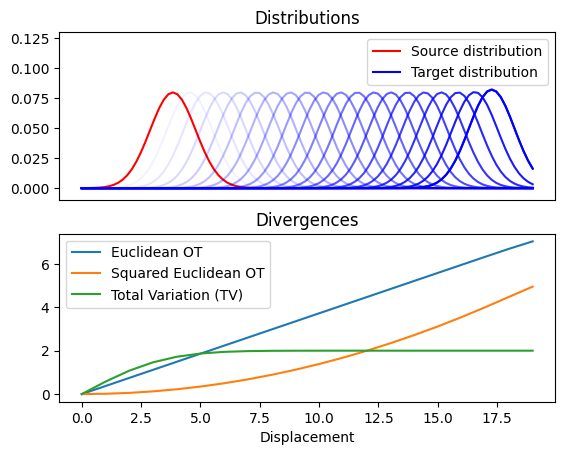

In [14]:
d_emd = ot.emd2(a, B, M) # direct computation of OT loss
d_emd2 = ot.emd2(a, B, M2) # direct computation of OT loss with metric M2
d_tv = [np.sum(abs(a - B[:, i])) for i in range(n_target)]

pl.figure(2)
pl.subplot(2, 1, 1)
pl.plot(x, a, "r", label="Source distribution")
pl.title("Distributions")
for i in range(n_target):
  pl.plot(x, B[:, i], "b", alpha=i / n_target)
pl.plot(x, B[:, -1], "b", label="Target distribution")
pl.ylim((-0.01, 0.13))
pl.xticks(())
pl.legend()
pl.subplot(2, 1, 2)
pl.plot(d_emd, label="Euclidean OT")
pl.plot(d_emd2, label="Squared Euclidean OT")
pl.plot(d_tv, label="Total Variation (TV)")
pl.xlabel("Displacement")
pl.title("Divergences")
pl.legend()

## Compute Sinkhorn for the different losses

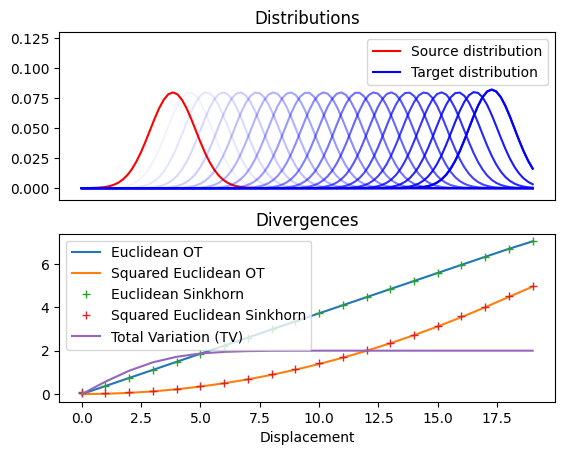

In [15]:
reg = 1e-1
d_sinhorn = ot.sinkhorn2(a, B, M, reg)
d_sinhorn2 = ot.sinkhorn2(a, B, M2, reg)

pl.figure(3)
pl.clf()

pl.subplot(2, 1, 1)
pl.plot(x, a, "r", label="Source distribution")
pl.title("Distributions")
for i in range(n_target):
  pl.plot(x, B[:, i], "b", alpha=i / n_target)
pl.plot(x, B[:, -1], "b", label="Target distribution")
pl.ylim((-0.01, 0.13))
pl.xticks(())
pl.legend()
pl.subplot(2, 1, 2)
pl.plot(d_emd, label="Euclidean OT")
pl.plot(d_emd2, label="Squared Euclidean OT")
pl.plot(d_sinhorn, "+", label="Euclidean Sinkhorn")
pl.plot(d_sinhorn2, "+", label="Squared Euclidean Sinkhorn")
pl.plot(d_tv, label="Total Variation (TV)")
pl.xlabel("Displacement")
pl.title("Divergences")
pl.legend()